In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [2]:
df = pd.read_csv("Retail_Store_Sales.csv")
df.head()

,Transaction ID,Customer ID,Product Category,Product Name,Quantity,Unit Price,Total Amount,Purchase Date,Customer City,Payment Method
0,T1,C158,Electronics,Headphones,4,3834,15336,6/4/2025,Multan,EasyPaisa
1,T2,C55,Beauty,Perfume,5,1561,7805,6/8/2025,Multan,Cash
2,T3,C50,Grocery,Cooking Oil,1,2290,2290,11/8/2025,Islamabad,Cash
3,T4,C276,Clothing,T-Shirt,4,3458,13832,9/16/2025,Karachi,JazzCash
4,T5,C262,Clothing,T-Shirt,2,4482,8964,6/5/2025,Islamabad,EasyPaisa


Dataset Shape

In [3]:
df.shape

(1000, 10)

Dataset Info

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   object
 1   Customer ID       1000 non-null   object
 2   Product Category  1000 non-null   object
 3   Product Name      1000 non-null   object
 4   Quantity          1000 non-null   int64 
 5   Unit Price        1000 non-null   int64 
 6   Total Amount      1000 non-null   int64 
 7   Purchase Date     1000 non-null   object
 8   Customer City     1000 non-null   object
 9   Payment Method    1000 non-null   object
dtypes: int64(3), object(7)
memory usage: 78.3+ KB


In [5]:
df.describe()

,Quantity,Unit Price,Total Amount
count,1000.000000,1000.000000,1000.000000
mean,2.984000,2738.289000,8115.254000
std,1.418364,1308.293289,5717.337214
min,1.000000,502.000000,513.000000
25%,2.000000,1606.250000,3674.000000
50%,3.000000,2720.000000,6539.000000
75%,4.000000,3849.750000,11529.000000
max,5.000000,4999.000000,24915.000000


Missing values check

In [6]:
df.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Product Category,0
Product Name,0
Quantity,0
Unit Price,0
Total Amount,0
Purchase Date,0
Customer City,0
Payment Method,0


Check duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

Monthly sale trend

In [8]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])
df["Month"] = df["Purchase Date"].dt.month

In [9]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales

,Total Amount
Month,
1,633060
2,607496
3,704176
4,786718
5,760010
6,759755
7,651080
8,602537
9,512730


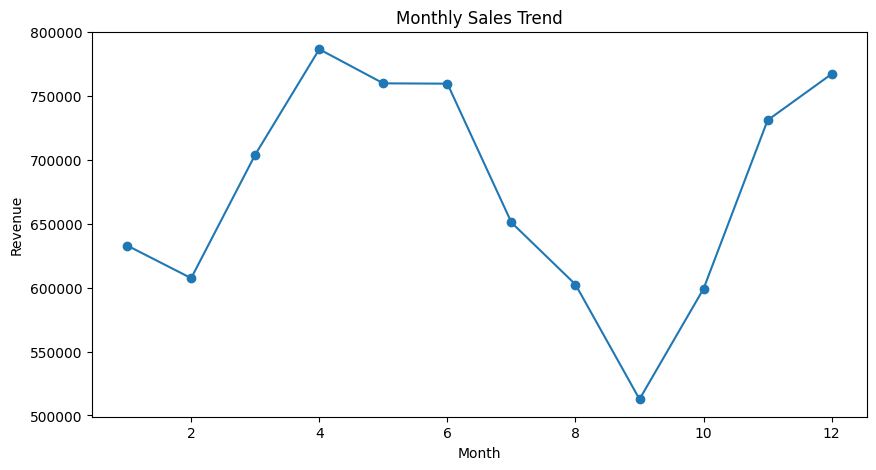

In [10]:
plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

Top Selling Product

In [11]:
top_products = df.groupby("Product Name")["Quantity"].sum().sort_values(ascending=False)
top_products

,Quantity
Product Name,
Rice Bag,351
T-Shirt,340
Mobile Charger,306
Perfume,302
Cooking Oil,301
Jeans,291
Blender,288
Microwave,279
Headphones,270


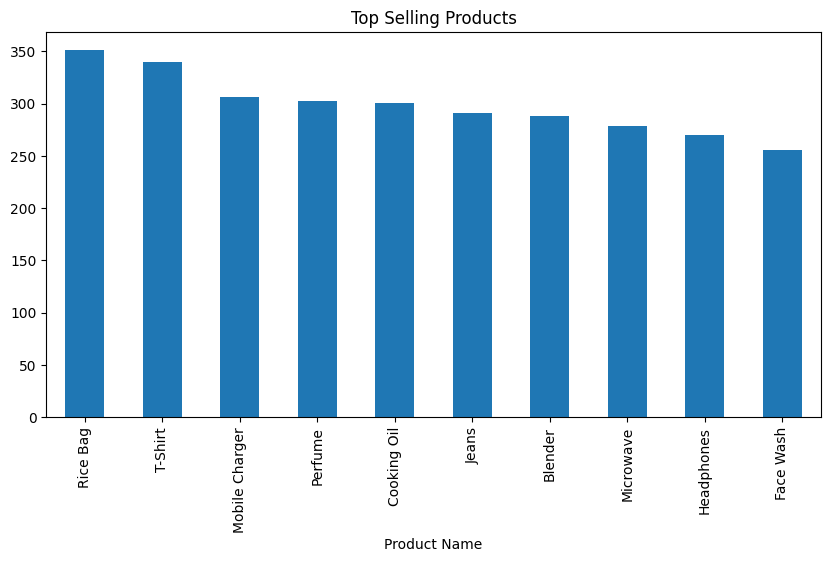

In [12]:
plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top Selling Products")
plt.show()

Top Categories

In [13]:
category_sales = df.groupby("Product Category")["Total Amount"].sum()
category_sales

,Total Amount
Product Category,
Beauty,1454994
Clothing,1706114
Electronics,1588655
Grocery,1807216
Home Appliances,1558275


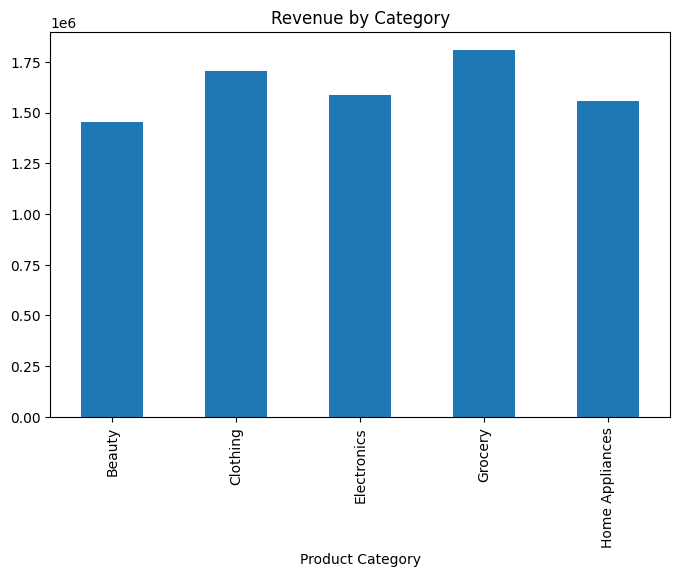

In [14]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.show()

Revenue by city

In [15]:
city_sales = df.groupby("Customer City")["Total Amount"].sum()
city_sales

,Total Amount
Customer City,
Faisalabad,1694484
Islamabad,1547552
Karachi,1693371
Lahore,1580102
Multan,1599745


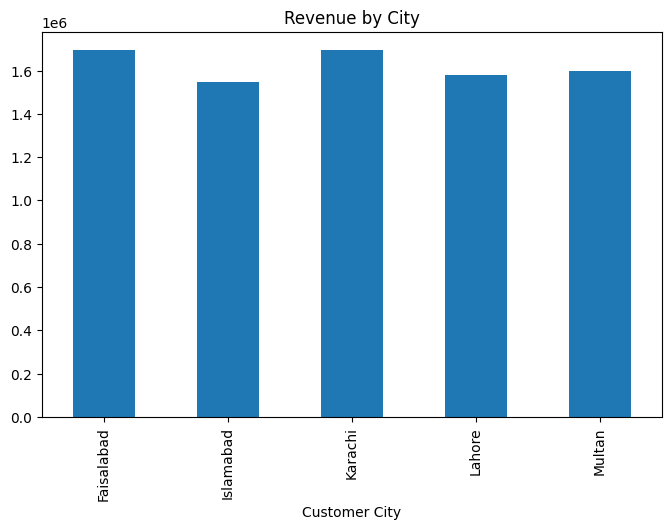

In [16]:
plt.figure(figsize=(8,5))
city_sales.plot(kind="bar")
plt.title("Revenue by City")
plt.show()


Payment Method distribution

In [17]:
payment_counts = df["Payment Method"].value_counts()
payment_counts

,count
Payment Method,
EasyPaisa,277
JazzCash,248
Cash,246
Card,229


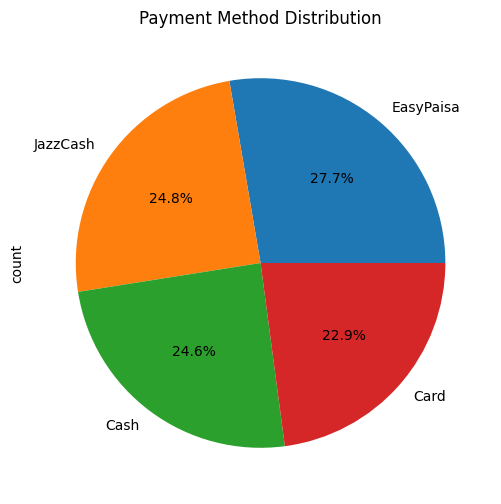

In [18]:
plt.figure(figsize=(6,6))
payment_counts.plot(kind="pie", autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

Average Order Value

In [19]:
df["Total Amount"].mean()

np.float64(8115.254)

Peak sale period

In [20]:
df.groupby("Month")["Quantity"].sum().sort_values(ascending=False)

,Quantity
Month,
5,285
4,274
12,272
11,263
6,262
1,254
7,249
2,241
3,236


Dashboard

In [21]:
df["Total Amount"].sum()

np.int64(8115254)

In [22]:
df["Transaction ID"].count()

np.int64(1000)

In [23]:
df["Total Amount"].mean()

np.float64(8115.254)

In [24]:
df.groupby("Customer City")["Quantity"].sum().sort_values(ascending=False)

,Quantity
Customer City,
Faisalabad,630
Karachi,603
Multan,588
Lahore,587
Islamabad,576


In [26]:
df["Payment Method"].value_counts()

,count
Payment Method,
EasyPaisa,277
JazzCash,248
Cash,246
Card,229


In [27]:
df.groupby("Product Category")["Quantity"].mean()

,Quantity
Product Category,
Beauty,3.000000
Clothing,3.033654
Electronics,2.953846
Grocery,3.004608
Home Appliances,2.922680
